# When Do Flights Leave Late? Seattle & Portland Departures, 2014

**Team:** [Member 1] · [Member 2] · [Member 3] · [Member 4]

## Business question
Operations at Seattle (SEA) and Portland (PDX) must decide where to put spare crews, gates and schedule buffer. **Which departures are most likely to leave more than 15 minutes late, and how much does weather matter compared with the schedule?**

## Summary
- **One flight in seven (14.4%)** left more than 15 minutes late.
- **Time of day matters most:** evening departures are delayed 18% of the time, early-morning ones 7%.
- **Carrier matters:** Southwest 27% vs Alaska 10%.
- **Weather matters only at the extremes**, such as freezing temperatures or poor visibility.
- **Our model ranks flights by risk well** (its top 10% are delayed 40% of the time) **but cannot predict exact delay minutes.**

## 0. Setup

In [1]:
# ---- Imports ----
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ---- Chart style: one consistent, colorblind-checked palette across the notebook ----
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
INK, INK2 = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.titlecolor": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
RNG = np.random.default_rng(42)

## 1. Data
- **`flights.csv`:** every 2014 departure from SEA and PDX (162,049 flights).
- **`weather.csv`:** hourly weather at each airport.

In [2]:
# ---- Load both CSV files ----
# In Colab: upload flights.csv and weather.csv via the file panel, or run this cell and pick both files.
FILES = ["flights.csv", "weather.csv"]
if not all(os.path.exists(f) for f in FILES):
    try:
        from google.colab import files
        print("Please upload flights.csv and weather.csv")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Put flights.csv and weather.csv in the same folder as this notebook.")

flights = pd.read_csv("flights.csv")
weather = pd.read_csv("weather.csv")
print(f"flights: {flights.shape[0]:,} rows x {flights.shape[1]} columns")
print(f"weather: {weather.shape[0]:,} rows x {weather.shape[1]} columns")
display(flights.head(3))
display(weather.head(3))

flights: 162,049 rows x 16 columns
weather: 14,446 rows x 14 columns


,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2014,1,1,1.00,96.00,235.00,70.00,AS,N508AS,145,PDX,ANC,194.00,1542,0.00,1.00
1,2014,1,1,4.00,-6.00,738.00,-23.00,US,N195UW,1830,SEA,CLT,252.00,2279,0.00,4.00
2,2014,1,1,8.00,13.00,548.00,-4.00,UA,N37422,1609,PDX,IAH,201.00,1825,0.00,8.00


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,PDX,2014,1,1,0,44.96,41.00,85.90,290.00,3.45,3.97,0.00,"1,026.90",8.00
1,PDX,2014,1,1,5,42.98,41.00,92.65,270.00,5.75,6.62,0.00,NaN,6.00
2,PDX,2014,1,1,6,42.98,42.08,96.60,290.00,3.45,3.97,0.00,"1,028.20",0.25


## 2. Combining the sources
Each flight is matched to the weather at its airport, in the same hour of the same day. We used a **left join**, which keeps every flight even when no weather record exists. Flights are what we are explaining, so none should disappear. We also checked that the join cannot duplicate flights.

In [3]:
# ---- Join: LEFT join flights -> weather on airport + date + hour ----
KEYS = ["origin", "year", "month", "day", "hour"]
weather["hour"] = weather["hour"].astype(float)          # flights.hour is float (it has NaNs), so types must match

# The weather table must be one row per airport-hour, otherwise the join would duplicate flights
assert not weather.duplicated(KEYS).any(), "weather has duplicate airport-hours"

df = flights.merge(weather, on=KEYS, how="left", indicator=True, validate="many_to_one")
assert len(df) == len(flights), "join changed the number of flights"

matched = (df["_merge"] == "both")
print(f"Flights in:            {len(flights):,}")
print(f"Matched to weather:    {matched.sum():,} ({matched.mean():.1%})")
print(f"No weather match:      {(~matched).sum():,} ({(~matched).mean():.1%})")

Flights in:            162,049
Matched to weather:    160,280 (98.9%)
No weather match:      1,769 (1.1%)


,flights,share_of_unmatched
reason,,
Weather station gap,893,0.50
Cancelled (no departure hour),857,0.48
Departed at 24:00 (hour=24),19,0.01


Weather-gap flights fall on 12 dates; top 5 dates hold 86% of them
Unmatched share by airport: {'PDX': 0.0127, 'SEA': 0.01}


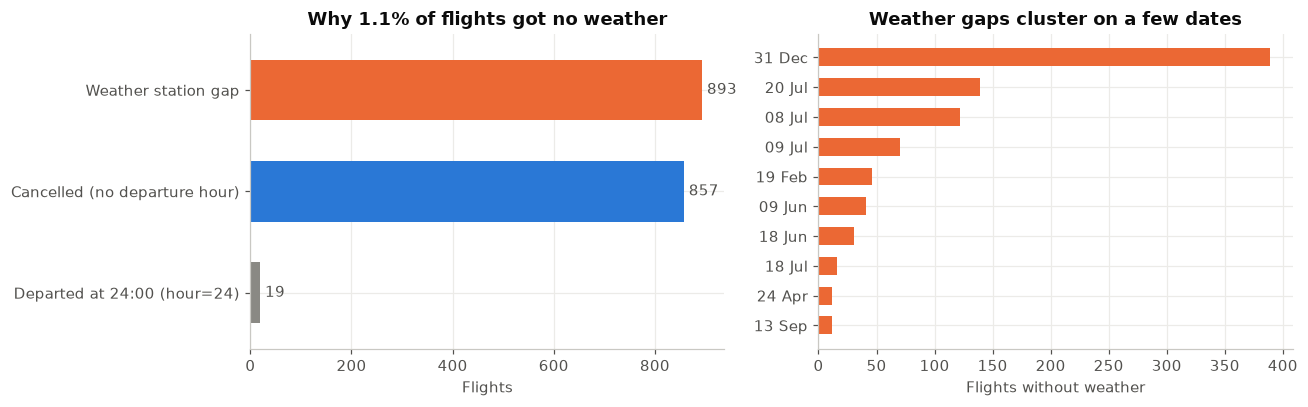

In [4]:
# ---- Do the unmatched rows have anything in common? ----
um = df[~matched].copy()
um["reason"] = np.select(
    [um["dep_time"].isna(), um["hour"].eq(24)],
    ["Cancelled (no departure hour)", "Departed at 24:00 (hour=24)"],
    default="Weather station gap",
)
reason_tbl = um["reason"].value_counts().rename("flights").to_frame()
reason_tbl["share_of_unmatched"] = reason_tbl["flights"] / len(um)
display(reason_tbl)

gaps = um[um["reason"] == "Weather station gap"]
gap_dates = (gaps.assign(date=pd.to_datetime(gaps[["year", "month", "day"]]))
                 .groupby("date").size().sort_values(ascending=False))
print(f"Weather-gap flights fall on {gap_dates.size} dates; top 5 dates hold {gap_dates.head(5).sum() / gap_dates.sum():.0%} of them")
print("Unmatched share by airport:", (~matched).groupby(df["origin"]).mean().round(4).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
reason_tbl["flights"].sort_values().plot.barh(ax=axes[0], color=[GREY, BLUE, ORANGE][:len(reason_tbl)], width=0.6)
axes[0].set_title("Why 1.1% of flights got no weather")
axes[0].set_xlabel("Flights"); axes[0].set_ylabel("")
for i, v in enumerate(reason_tbl["flights"].sort_values()):
    axes[0].text(v + 10, i, f"{v:,}", va="center", color=INK2)
top = gap_dates.head(10).sort_values()
axes[1].barh(top.index.strftime("%d %b"), top.values, color=ORANGE, height=0.6)
axes[1].set_title("Weather gaps cluster on a few dates")
axes[1].set_xlabel("Flights without weather")
plt.tight_layout(); plt.show()

**What the join cost:** 98.9% of flights matched; **1,769 (1.1%) did not**. The unmatched flights are not random. They fall into three groups:
- **857 cancelled flights**, which have no departure hour to match on.
- **893 flights on days the weather station has no records**, mostly on five dates. New Year's Eve alone accounts for 389.
- **19 flights recorded at "hour 24"** (midnight).

The gaps sit on specific dates rather than in particular carriers or weather types, so losing them does not bias the findings.

## 3. What the data contains and its condition
The combined table covers 2 airports, 71 destinations, 11 carriers and all of 2014. It is mostly complete. Only air pressure (17% missing) and wind direction (4% missing) have real gaps.

162,049 rows, 25 columns | 2 origins, 71 destinations, 11 carriers, year [2014]


,count,mean,50%,min,max
year,"162,049.00","2,014.00","2,014.00","2,014.00","2,014.00"
month,"162,049.00",6.61,7.00,1.00,12.00
day,"162,049.00",15.75,16.00,1.00,31.00
dep_time,"161,192.00","1,278.28","1,217.00",1.00,"2,400.00"
dep_delay,"161,192.00",6.13,-2.00,-37.00,"1,553.00"
arr_time,"161,061.00","1,482.50","1,517.00",1.00,"2,400.00"
arr_delay,"160,748.00",2.24,-4.00,-67.00,"1,539.00"
flight,"162,049.00","1,357.36",694.00,2.00,"6,527.00"
air_time,"160,748.00",152.59,129.00,18.00,422.00
distance,"162,049.00","1,204.51",991.00,93.00,"2,724.00"


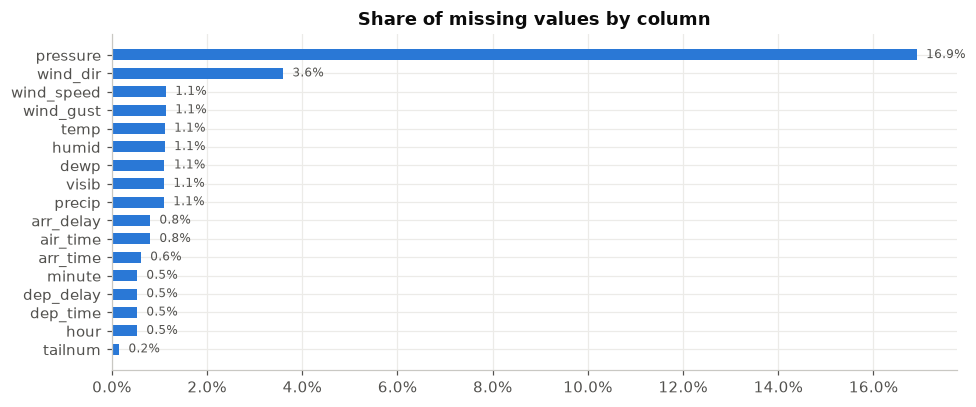

In [5]:
# ---- What does the combined table contain? ----
print(f"{df.shape[0]:,} rows, {df.shape[1]-1} columns | {df['origin'].nunique()} origins, "
      f"{df['dest'].nunique()} destinations, {df['carrier'].nunique()} carriers, year {df['year'].unique()}")
display(df.drop(columns="_merge").describe().T[["count", "mean", "50%", "min", "max"]])

# ---- Missing values ----
miss = df.drop(columns="_merge").isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(miss.index[::-1], miss.values[::-1], color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Share of missing values by column")
for i, v in enumerate(miss.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=8, color=INK2)
plt.tight_layout(); plt.show()

In [6]:
# ---- Things that look wrong ----
print("Dew point > 100F (impossible for this climate):", (df["dewp"] > 100).sum(), "rows, value(s):", df.loc[df["dewp"] > 100, "dewp"].unique())
ratio = (weather["wind_gust"] / weather["wind_speed"]).replace([np.inf], np.nan).dropna()
print(f"wind_gust / wind_speed ratio: min {ratio.min():.4f}, max {ratio.max():.4f}  -> gust is a copy of speed x 1.15")
print("Flights with hour = 24:", df["hour"].eq(24).sum())
print("pressure missing:", f"{df['pressure'].isna().mean():.1%}")
print(f"dep_delay: median {df['dep_delay'].median():.0f} min, mean {df['dep_delay'].mean():.1f} min, "
      f"99th pct {df['dep_delay'].quantile(.99):.0f} min, max {df['dep_delay'].max():.0f} min")

Dew point > 100F (impossible for this climate): 6 rows, value(s): [3282.8]
wind_gust / wind_speed ratio: min 1.1508, max 1.1508  -> gust is a copy of speed x 1.15
Flights with hour = 24: 19
pressure missing: 16.9%
dep_delay: median -2 min, mean 6.1 min, 99th pct 127 min, max 1553 min


We found four problems:
- **An impossible dew point** (3,282°F) in 6 rows.
- **Wind gust is not a real measurement.** It equals wind speed × 1.15 in every row.
- **Air pressure is missing for 17% of flights.**
- **"hour" records when the flight actually left, not when it was scheduled.** A 7pm flight delayed three hours shows as 10pm. Used as it is, this makes late flights look like they were scheduled late: flights that actually left between 1am and 4am averaged 105 minutes late, yet only 26 were scheduled then.

In [7]:
# ---- Cleaning (every step logged) ----
log = []
clean = df.drop(columns="_merge").copy()

before = clean["dewp"].corr(clean["dep_delay"])
n = (clean["dewp"] > 100).sum(); clean.loc[clean["dewp"] > 100, "dewp"] = np.nan
log.append(["Dew point > 100F set to missing", "Physically impossible (sensor/entry error)", n])

n = clean["hour"].eq(24).sum(); clean.loc[clean["hour"].eq(24), "hour"] = 0
log.append(["hour 24 recoded to 0", "24:00 is midnight; keeps hour in 0-23", n])

clean["cancelled"] = clean["dep_time"].isna()
n = clean["cancelled"].sum()
log.append(["Cancelled flights excluded from delay analysis", "No delay exists to measure; reported separately", n])

clean = clean.drop(columns=["wind_gust", "pressure"])
log.append(["Dropped wind_gust", "Exact copy of wind_speed x 1.15, adds no information", len(clean)])
log.append(["Dropped pressure", f"{df['pressure'].isna().mean():.0%} missing; imputing would invent data", len(clean)])

n = clean["tailnum"].isna().sum()
log.append(["Kept rows with missing tailnum", "Aircraft ID is not used in the analysis", n])

clean["delayed15"] = (clean["dep_delay"] > 15).astype(int)   # industry (FAA) definition of a delay
clean["season"] = clean["month"].map({12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
                                      6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"})
log.append(["Added delayed15 flag and season", "FAA defines 'delayed' as >15 min; season aids grouping", len(clean)])

# 'hour' is the ACTUAL departure hour (dep_time // 100), so a late flight moves into a later hour.
# Using it to explain delay is circular (leakage). Rebuild the SCHEDULED hour = actual time - delay.
dep_min = (clean["dep_time"] // 100) * 60 + clean["dep_time"] % 100
clean["sched_hour"] = (((dep_min - clean["dep_delay"]) % 1440) // 60)
n = (clean["sched_hour"] != clean["hour"]).sum()
log.append(["Added sched_hour (scheduled departure hour)", "'hour' is actual departure hour; it leaks the delay", n])
print("Mean delay of flights that ACTUALLY left 1-4am:", round(clean.loc[clean.hour.between(1, 4), "dep_delay"].mean()),
      "min; flights SCHEDULED 1-4am:", (clean["sched_hour"].between(1, 4)).sum())

# Analysis set: flights that departed AND have weather
flown = clean[~clean["cancelled"] & clean["temp"].notna()].copy()
log.append(["Analysis set = departed flights with weather", "Needed for weather comparisons and the model", len(flown)])

cleaning_log = pd.DataFrame(log, columns=["Decision", "Why", "Rows affected"])
display(cleaning_log)

print(f"Dew point vs delay correlation: before fix {before:.4f}, after fix {clean['dewp'].corr(clean['dep_delay']):.4f}")
cap = flown["dep_delay"].clip(upper=flown["dep_delay"].quantile(.99))
print(f"Mean delay with all flights {flown['dep_delay'].mean():.2f} min vs. capped at 99th pct {cap.mean():.2f} min "
      "-> extreme delays are real events, kept in the data")

Mean delay of flights that ACTUALLY left 1-4am: 105 min; flights SCHEDULED 1-4am: 26


,Decision,Why,Rows affected
0,Dew point > 100F set to missing,Physically impossible (sensor/entry error),6
1,hour 24 recoded to 0,24:00 is midnight; keeps hour in 0-23,19
2,Cancelled flights excluded from delay analysis,No delay exists to measure; reported separately,857
3,Dropped wind_gust,"Exact copy of wind_speed x 1.15, adds no infor...",162049
4,Dropped pressure,17% missing; imputing would invent data,162049
5,Kept rows with missing tailnum,Aircraft ID is not used in the analysis,248
6,Added delayed15 flag and season,FAA defines 'delayed' as >15 min; season aids ...,162049
7,Added sched_hour (scheduled departure hour),'hour' is actual departure hour; it leaks the ...,35448
8,Analysis set = departed flights with weather,Needed for weather comparisons and the model,160247


Dew point vs delay correlation: before fix -0.0140, after fix -0.0272
Mean delay with all flights 6.13 min vs. capped at 99th pct 5.37 min -> extreme delays are real events, kept in the data


**Each cleaning decision and its reason is in the table above.** What difference they made:
- **Fixing the dew point** doubled its correlation with delay. One bad value had been hiding the relationship.
- **Rebuilding the scheduled hour** changed the story: the apparent "worst hours" of 1–4am turned out to be evening flights that slipped past midnight.
- **We kept extreme delays.** They are real events, and dropping the worst 1% would lower the average delay only from 6.1 to 5.4 minutes.

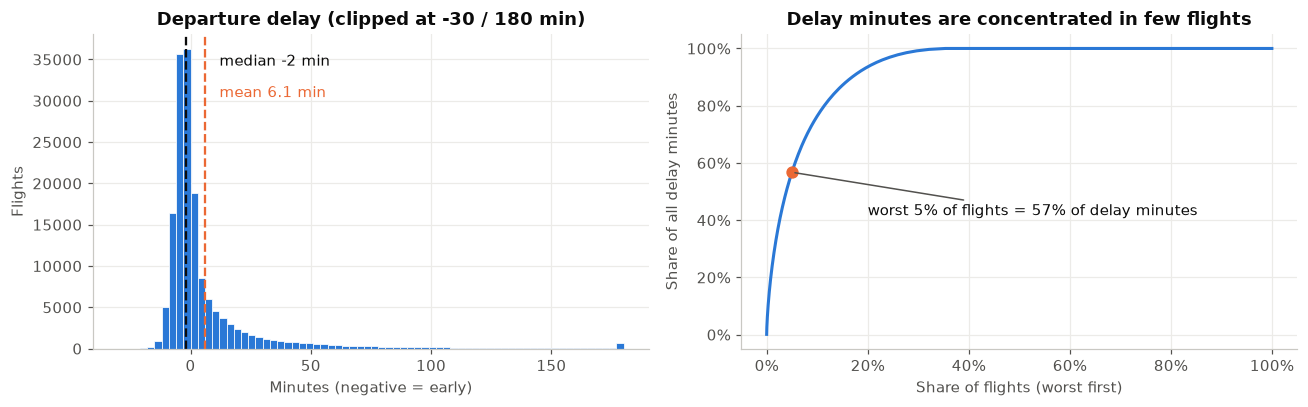

In [8]:
# ---- Shape of the target: most flights leave early, a few are very late ----
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(flown["dep_delay"].clip(-30, 180), bins=70, color=BLUE, edgecolor="white", linewidth=0.5)
for v, lab, c in [(flown["dep_delay"].median(), "median", INK), (flown["dep_delay"].mean(), "mean", ORANGE)]:
    axes[0].axvline(v, color=c, lw=1.5, ls="--")
axes[0].text(12, axes[0].get_ylim()[1] * .9, f"median {flown['dep_delay'].median():.0f} min", color=INK)
axes[0].text(12, axes[0].get_ylim()[1] * .8, f"mean {flown['dep_delay'].mean():.1f} min", color=ORANGE)
axes[0].set_title("Departure delay (clipped at -30 / 180 min)")
axes[0].set_xlabel("Minutes (negative = early)"); axes[0].set_ylabel("Flights")

# Pareto: what share of all delay minutes comes from the worst flights?
late = np.sort(flown["dep_delay"].clip(lower=0).values)[::-1]
cum = np.cumsum(late) / late.sum()
x = np.arange(1, len(late) + 1) / len(late)
axes[1].plot(x, cum, color=BLUE, lw=2)
share5 = cum[int(len(late) * .05) - 1]
axes[1].scatter([.05], [share5], color=ORANGE, s=50, zorder=3)
axes[1].annotate(f"worst 5% of flights = {share5:.0%} of delay minutes", (.05, share5), xytext=(.2, share5 - .15),
                 color=INK, arrowprops=dict(arrowstyle="-", color=INK2))
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Delay minutes are concentrated in few flights")
axes[1].set_xlabel("Share of flights (worst first)"); axes[1].set_ylabel("Share of all delay minutes")
plt.tight_layout(); plt.show()

**The typical flight leaves 2 minutes early, yet the average is 6 minutes late.** The worst 5% of flights cause 57% of all delay minutes. We therefore measure risk mainly as the **chance of a delay over 15 minutes**, the industry's standard definition.

## 4. Baseline
Before modelling, we tested the simplest possible answer on 20% of flights held back from model building:
- **"Every flight is as late as the average flight"** is off by **14.2 minutes** on average.
- **"Every flight is on time"** is right **85.5%** of the time, but it never catches a delay.

Any model must beat these.

In [9]:
# ---- Baseline: predict the same number for every flight ----
FEATURES = ["dep_delay", "delayed15", "sched_hour", "month", "carrier", "origin", "season",
            "visib", "wind_speed", "precip", "humid", "temp", "distance"]
model_df = flown[FEATURES].dropna().copy()
model_df["hour"] = model_df.pop("sched_hour").astype(int)   # models use the SCHEDULED hour
train, test = train_test_split(model_df, test_size=0.2, random_state=42)
print(f"Train {len(train):,} flights | Test {len(test):,} flights")

def scores(y, pred):
    return {"MAE (min)": mean_absolute_error(y, pred),
            "RMSE (min)": mean_squared_error(y, pred) ** 0.5,
            "R2": r2_score(y, pred)}

baseline = pd.DataFrame({
    "Predict the mean": scores(test["dep_delay"], np.full(len(test), train["dep_delay"].mean())),
    "Predict the median": scores(test["dep_delay"], np.full(len(test), train["dep_delay"].median())),
}).T
display(baseline)

base_rate = train["delayed15"].mean()
print(f"Share of flights delayed >15 min (train): {base_rate:.1%}")
print(f"'Every flight is on time' is right {1 - test['delayed15'].mean():.1%} of the time - but catches 0% of delays.")

Train 128,166 flights | Test 32,042 flights


,MAE (min),RMSE (min),R2
Predict the mean,14.23,27.98,-0.00
Predict the median,11.39,29.11,-0.08


Share of flights delayed >15 min (train): 14.4%
'Every flight is on time' is right 85.5% of the time - but catches 0% of delays.


## 5. What drives delay?

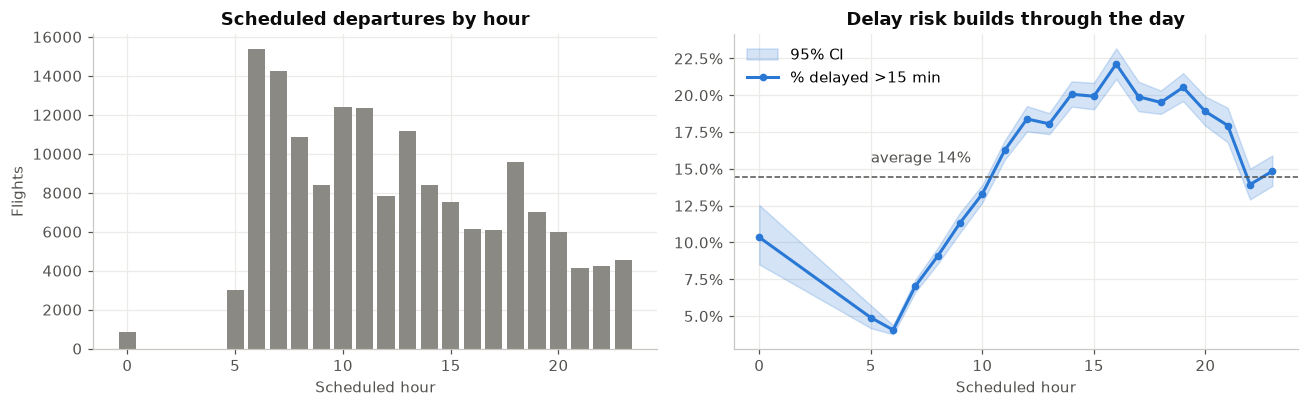

In [10]:
# ---- Helper: proportion with 95% Wilson confidence interval ----
def prop_ci(s):
    k, n = s.sum(), s.count()
    lo, hi = stats.binomtest(int(k), int(n)).proportion_ci(confidence_level=0.95, method="wilson")
    return pd.Series({"rate": k / n, "lo": lo, "hi": hi, "n": n})

# ---- V1: time of day ----
by_hour = flown.groupby("sched_hour")["delayed15"].apply(prop_ci).unstack()
by_hour = by_hour[by_hour["n"] >= 200]                       # hide hours with too few flights to trust
vol = flown["sched_hour"].value_counts().sort_index().loc[by_hour.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(vol.index, vol.values, color=GREY, width=0.8)
axes[0].set_title("Scheduled departures by hour"); axes[0].set_xlabel("Scheduled hour"); axes[0].set_ylabel("Flights")
axes[1].fill_between(by_hour.index, by_hour["lo"], by_hour["hi"], color=BLUE, alpha=.2, label="95% CI")
axes[1].plot(by_hour.index, by_hour["rate"], color=BLUE, lw=2, marker="o", ms=4, label="% delayed >15 min")
axes[1].axhline(base_rate, color=INK2, ls="--", lw=1); axes[1].text(5, base_rate + .01, f"average {base_rate:.0%}", color=INK2)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Delay risk builds through the day"); axes[1].set_xlabel("Scheduled hour"); axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

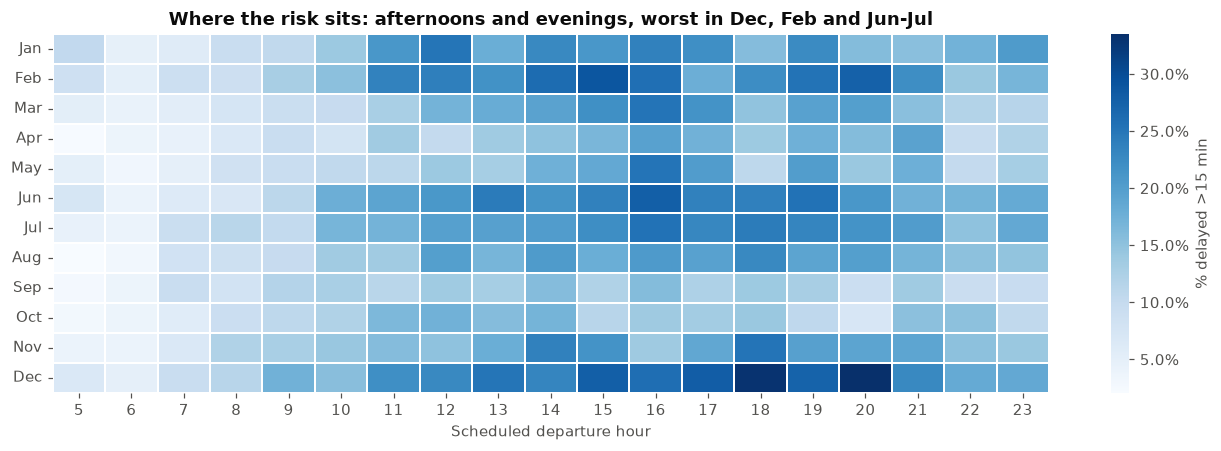

In [11]:
# ---- V2: month x hour heatmap ----
heat = flown[flown["sched_hour"].between(5, 23)].astype({"sched_hour": int}).pivot_table(index="month", columns="sched_hour", values="delayed15", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 4.2))
sns.heatmap(heat, cmap="Blues", ax=ax, cbar_kws={"format": mtick.PercentFormatter(1), "label": "% delayed >15 min"},
            linewidths=1, linecolor="white")
ax.set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=0)
ax.set_title("Where the risk sits: afternoons and evenings, worst in Dec, Feb and Jun-Jul"); ax.set_xlabel("Scheduled departure hour"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

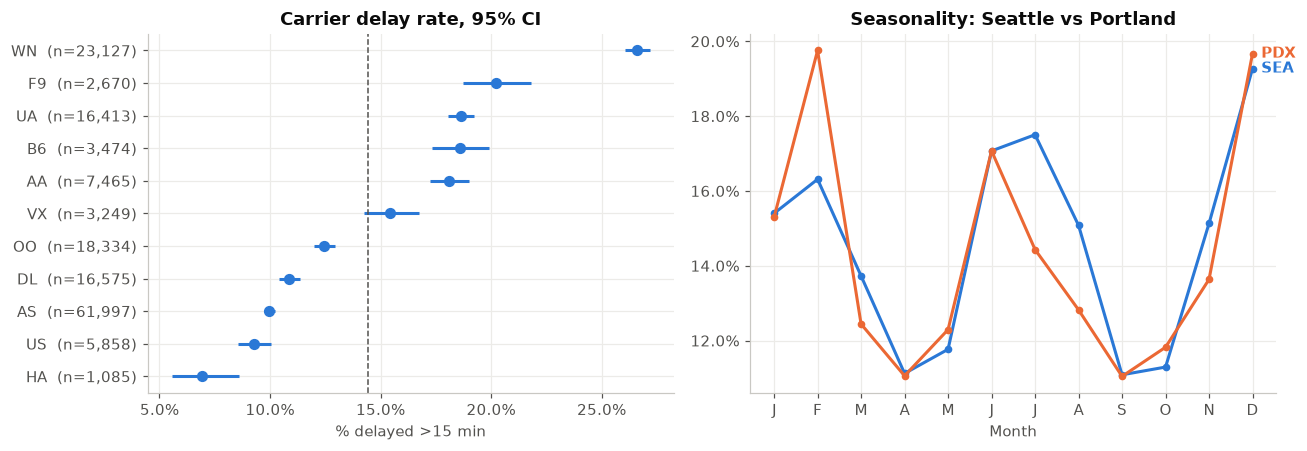

In [12]:
# ---- V3: carriers (with 95% CI) and V4: airport by month ----
by_car = flown.groupby("carrier")["delayed15"].apply(prop_ci).unstack().sort_values("rate")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.hlines(range(len(by_car)), by_car["lo"], by_car["hi"], color=BLUE, lw=2)
ax.scatter(by_car["rate"], range(len(by_car)), color=BLUE, s=40, zorder=3)
ax.axvline(base_rate, color=INK2, ls="--", lw=1)
ax.set_yticks(range(len(by_car))); ax.set_yticklabels([f"{c}  (n={int(n):,})" for c, n in zip(by_car.index, by_car["n"])])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Carrier delay rate, 95% CI"); ax.set_xlabel("% delayed >15 min")

by_m = flown.groupby(["month", "origin"])["delayed15"].mean().unstack()
for col, c in [("SEA", BLUE), ("PDX", ORANGE)]:
    axes[1].plot(by_m.index, by_m[col], color=c, lw=2, marker="o", ms=4)
    axes[1].text(12.2, by_m[col].iloc[-1], col, color=c, va="center", fontweight="bold")
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(list("JFMAMJJASOND"))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Seasonality: Seattle vs Portland"); axes[1].set_xlabel("Month")
plt.tight_layout(); plt.show()

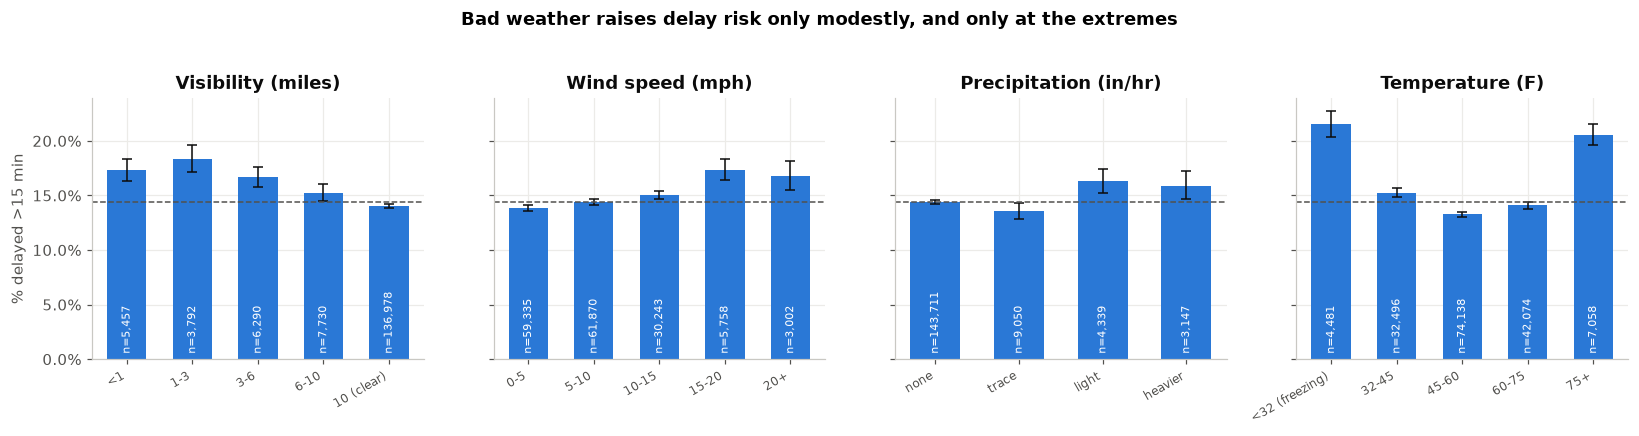

In [13]:
# ---- V5: does weather matter? Delay rate across weather bands ----
bands = {
    "visib": ([-0.1, 1, 3, 6, 9.9, 10], ["<1", "1-3", "3-6", "6-10", "10 (clear)"], "Visibility (miles)"),
    "wind_speed": ([-0.1, 5, 10, 15, 20, 40], ["0-5", "5-10", "10-15", "15-20", "20+"], "Wind speed (mph)"),
    "precip": ([-0.01, 0, 0.02, 0.05, 1], ["none", "trace", "light", "heavier"], "Precipitation (in/hr)"),
    "temp": ([0, 32, 45, 60, 75, 100], ["<32 (freezing)", "32-45", "45-60", "60-75", "75+"], "Temperature (F)"),
}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (col, (bins, labels, title)) in zip(axes, bands.items()):
    g = flown.assign(b=pd.cut(flown[col], bins, labels=labels)).groupby("b", observed=True)["delayed15"].apply(prop_ci).unstack()
    ax.bar(range(len(g)), g["rate"], color=BLUE, width=0.6)
    ax.errorbar(range(len(g)), g["rate"], yerr=[g["rate"] - g["lo"], g["hi"] - g["rate"]], fmt="none", ecolor=INK, capsize=3, lw=1)
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30, ha="right", fontsize=8)
    for i, n in enumerate(g["n"]):
        ax.text(i, 0.005, f"n={int(n):,}", ha="center", fontsize=7, color="white", rotation=90, va="bottom")
    ax.axhline(base_rate, color=INK2, ls="--", lw=1); ax.set_title(title)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[0].set_ylabel("% delayed >15 min")
plt.suptitle("Bad weather raises delay risk only modestly, and only at the extremes", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

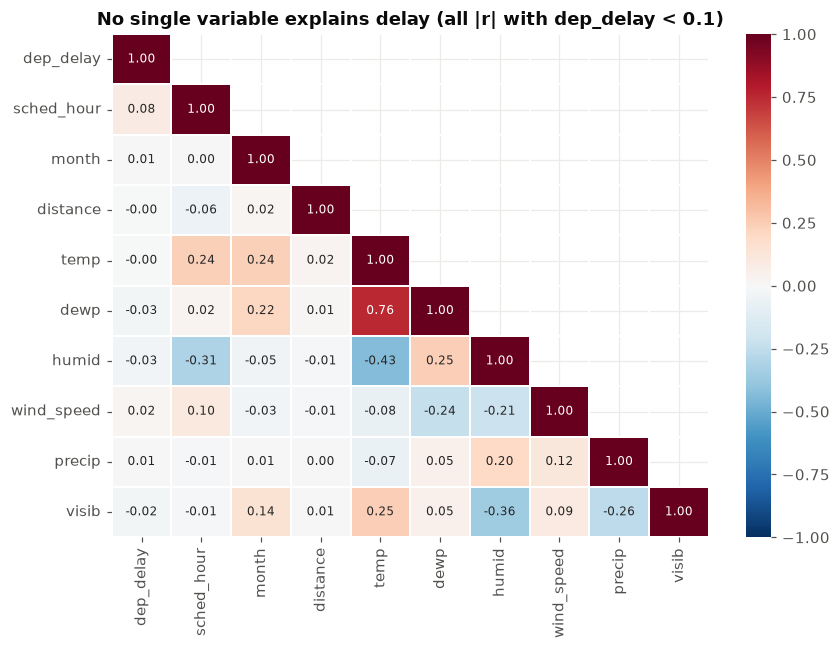

sched_hour    0.08
humid        -0.03
dewp         -0.03
visib        -0.03
wind_speed    0.02
precip        0.01
month         0.01
distance     -0.00
temp         -0.00
Name: dep_delay, dtype: float64


In [14]:
# ---- V6: correlation of numeric drivers with delay ----
num = ["dep_delay", "sched_hour", "month", "distance", "temp", "dewp", "humid", "wind_speed", "precip", "visib"]
corr = flown[num].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"size": 8},
            mask=np.triu(np.ones_like(corr, dtype=bool), 1), linewidths=1, linecolor="white", ax=ax)
ax.set_title("No single variable explains delay (all |r| with dep_delay < 0.1)")
plt.tight_layout(); plt.show()
print(corr["dep_delay"].drop("dep_delay").sort_values(key=abs, ascending=False).round(3))

**What the charts show:**
- **Risk builds through the day**, from 4% at 6am to 22% at 4pm. Morning delays carry through to the aircraft's later flights.
- **Season matters:** December, February and June–July afternoons are worst; spring and autumn are calmest.
- **Carrier gaps are real** (the confidence bars do not overlap): Southwest is delayed more than twice as often as Alaska.
- **Seattle and Portland behave alike**, so one plan fits both.
- **Weather matters only at the extremes.** Freezing temperatures, visibility under 3 miles and strong wind each raise risk by a few points, and only about 1 flight in 8 departs in any of these conditions.
- **No single factor explains delay** (every correlation is below 0.1).

## 6. How sure are we?
These results come from one year of flights, so they are estimates. Each comes with a **95% confidence interval**: a range likely to contain the true value.

In [15]:
# ---- Bootstrap: overall estimates ----
B = 2000
d = flown["dep_delay"].values; f15 = flown["delayed15"].values
boot_mean, boot_rate = [], []
for _ in range(B):
    i = RNG.integers(0, len(d), len(d))
    boot_mean.append(d[i].mean()); boot_rate.append(f15[i].mean())
print(f"Mean delay: {d.mean():.2f} min, 95% CI [{np.percentile(boot_mean, 2.5):.2f}, {np.percentile(boot_mean, 97.5):.2f}]")
print(f"% delayed >15: {f15.mean():.2%}, 95% CI [{np.percentile(boot_rate, 2.5):.2%}, {np.percentile(boot_rate, 97.5):.2%}]")

Mean delay: 6.13 min, 95% CI [5.99, 6.28]
% delayed >15: 14.44%, 95% CI [14.25%, 14.61%]


,diff,lo,hi,p,n_a,n_b
Any precipitation vs none,+0.3%,-0.2%,+0.9%,2.5e-01,"16,536","143,711"
SEA vs PDX,+0.4%,+0.1%,+0.8%,2.0e-02,"107,596","52,651"
Wind 20+ mph vs <20,+2.4%,+1.0%,+3.7%,2.2e-04,"3,002","157,206"
Low visibility (<3 mi) vs clear,+3.2%,+2.4%,+4.1%,8.8e-16,"7,961","136,978"
December vs rest of year,+5.4%,+4.7%,+6.1%,3.3e-60,"12,443","147,804"
Freezing (<32F) vs not,+8.0%,+6.6%,+9.4%,9.2e-41,"3,542","156,705"
Evening (17-23h) vs morning (5-9h),+11.3%,+10.8%,+11.7%,0.0e+00,"41,637","51,862"


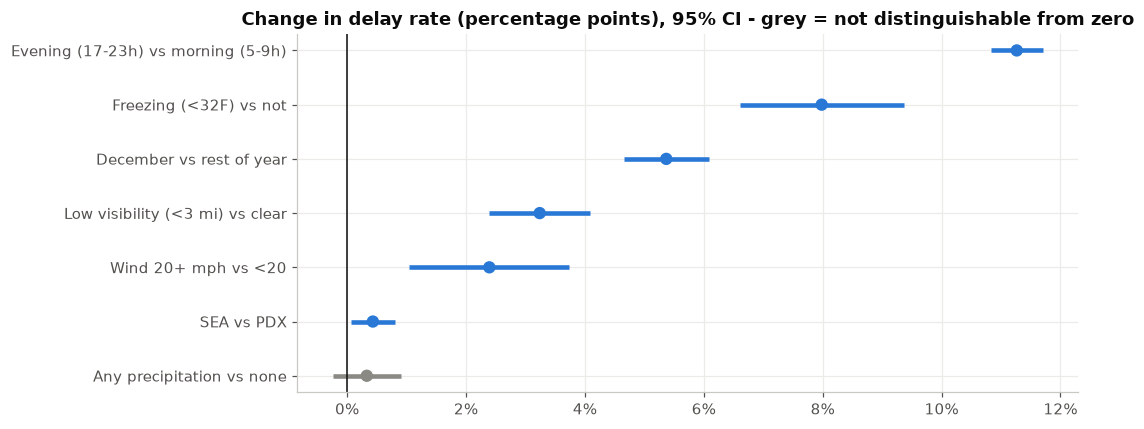

In [16]:
# ---- Comparisons that drive the recommendation: difference in delay rate with 95% CI ----
def diff_ci(a, b):
    """Difference in proportions a - b with a normal-approximation 95% CI and two-proportion z-test p-value."""
    p1, p2, n1, n2 = a.mean(), b.mean(), len(a), len(b)
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    pooled = (a.sum() + b.sum()) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    return {"diff": p1 - p2, "lo": p1 - p2 - 1.96 * se, "hi": p1 - p2 + 1.96 * se, "p": 2 * stats.norm.sf(abs(z)), "n_a": n1, "n_b": n2}

F = flown
comparisons = pd.DataFrame({
    "Evening (17-23h) vs morning (5-9h)": diff_ci(F.loc[F.sched_hour.between(17, 23), "delayed15"], F.loc[F.sched_hour.between(5, 9), "delayed15"]),
    "Low visibility (<3 mi) vs clear": diff_ci(F.loc[F.visib < 3, "delayed15"], F.loc[F.visib >= 10, "delayed15"]),
    "Freezing (<32F) vs not": diff_ci(F.loc[F.temp < 32, "delayed15"], F.loc[F.temp >= 32, "delayed15"]),
    "Wind 20+ mph vs <20": diff_ci(F.loc[F.wind_speed >= 20, "delayed15"], F.loc[F.wind_speed < 20, "delayed15"]),
    "Any precipitation vs none": diff_ci(F.loc[F.precip > 0, "delayed15"], F.loc[F.precip == 0, "delayed15"]),
    "December vs rest of year": diff_ci(F.loc[F.month == 12, "delayed15"], F.loc[F.month != 12, "delayed15"]),
    "SEA vs PDX": diff_ci(F.loc[F.origin == "SEA", "delayed15"], F.loc[F.origin == "PDX", "delayed15"]),
}).T.sort_values("diff")
display(comparisons.style.format({"diff": "{:+.1%}", "lo": "{:+.1%}", "hi": "{:+.1%}", "p": "{:.1e}", "n_a": "{:,.0f}", "n_b": "{:,.0f}"}))

fig, ax = plt.subplots(figsize=(10, 4))
y = range(len(comparisons))
sig = comparisons["lo"].gt(0) | comparisons["hi"].lt(0)
ax.hlines(y, comparisons["lo"], comparisons["hi"], color=[BLUE if s else GREY for s in sig], lw=3)
ax.scatter(comparisons["diff"], y, color=[BLUE if s else GREY for s in sig], s=50, zorder=3)
ax.axvline(0, color=INK, lw=1)
ax.set_yticks(list(y)); ax.set_yticklabels(comparisons.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_title("Change in delay rate (percentage points), 95% CI - grey = not distinguishable from zero")
plt.tight_layout(); plt.show()

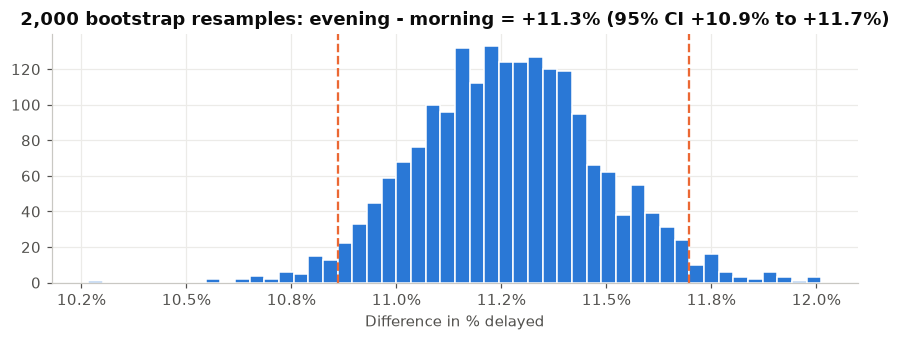

In [17]:
# ---- Bootstrap check of the biggest effect (evening vs morning), no normality assumption ----
eve = F.loc[F.sched_hour.between(17, 23), "delayed15"].values; mor = F.loc[F.sched_hour.between(5, 9), "delayed15"].values
boot = np.array([RNG.choice(eve, len(eve)).mean() - RNG.choice(mor, len(mor)).mean() for _ in range(2000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(boot, bins=50, color=BLUE, edgecolor="white")
for v in (lo, hi): ax.axvline(v, color=ORANGE, ls="--")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1))
ax.set_title(f"2,000 bootstrap resamples: evening - morning = {boot.mean():+.1%} (95% CI {lo:+.1%} to {hi:+.1%})")
ax.set_xlabel("Difference in % delayed"); plt.tight_layout(); plt.show()

A blue bar that does not touch zero means the effect is real, not chance.
- **The overall delay rate is 14.4%** (range 14.3%–14.6%).
- **Evening vs morning is the largest and most certain effect:** +11.3 points (10.9–11.7). A bootstrap test, which makes no statistical assumptions, gives the same answer.
- **Freezing temperatures (+8.0 points), December (+5.4), low visibility (+3.2) and strong wind (+2.4)** are all real effects.
- **Rain alone makes no detectable difference.**
- **Seattle is only 0.4 points worse than Portland**, too small to matter.

## 7. Regression model
**How we chose the variables:** we used only information known *before* departure: scheduled hour, month, carrier, airport, distance and the weather at departure. Arrival delay and actual departure time were excluded, because they would give away the answer. We added the variables in groups and kept each group only if it reduced error on the held-back flights.

,MAE (min),RMSE (min),R2,Train R2,Parameters
Predict the mean,14.23,27.98,-0.00,0.00,1.00
Predict the median,11.39,29.11,-0.08,0.00,1.00
1. Weather only,14.19,27.94,0.00,0.00,6.00
2. Time only,13.79,27.76,0.02,0.02,32.00
3. Time + carrier + airport,13.47,27.44,0.04,0.04,43.00
4. Full (3 + weather),13.49,27.42,0.04,0.04,49.00


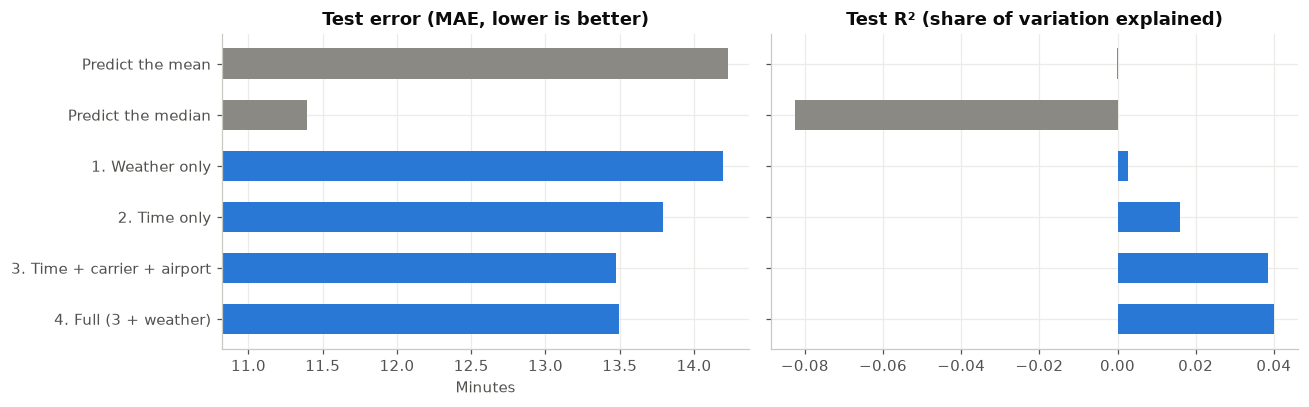

In [18]:
# ---- Build models step by step and keep only what helps on unseen data ----
specs = {
    "1. Weather only":            "dep_delay ~ visib + wind_speed + precip + humid + temp",
    "2. Time only":               "dep_delay ~ C(hour) + C(month)",
    "3. Time + carrier + airport": "dep_delay ~ C(hour) + C(month) + C(carrier) + origin",
    "4. Full (3 + weather)":      "dep_delay ~ C(hour) + C(month) + C(carrier) + origin + visib + wind_speed + precip + humid + temp + distance",
}
rows, fitted = {}, {}
for name, f in specs.items():
    m = smf.ols(f, data=train).fit()
    fitted[name] = m
    rows[name] = {**scores(test["dep_delay"], m.predict(test)), "Train R2": m.rsquared, "Parameters": len(m.params)}
results = pd.concat([baseline.assign(**{"Train R2": 0.0, "Parameters": 1}), pd.DataFrame(rows).T])
display(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
colors = [GREY, GREY] + [BLUE] * len(specs)
axes[0].barh(results.index[::-1], results["MAE (min)"][::-1], color=colors[::-1], height=0.6)
axes[0].set_xlim(results["MAE (min)"].min() * .95, results["MAE (min)"].max() * 1.01)
axes[0].set_title("Test error (MAE, lower is better)"); axes[0].set_xlabel("Minutes")
axes[1].barh(results.index[::-1], results["R2"][::-1], color=colors[::-1], height=0.6)
axes[1].set_title("Test R² (share of variation explained)"); axes[1].set_yticklabels([])
plt.tight_layout(); plt.show()

**How well it performs:**
- **Weather alone adds almost nothing.** Time, carrier and airport do the work.
- **The best model explains only 4% of the variation in delay minutes.** Its typical error is 13.5 minutes, about 5% better than guessing the average for every flight.
- **Exact delay minutes are essentially unpredictable** from this data.

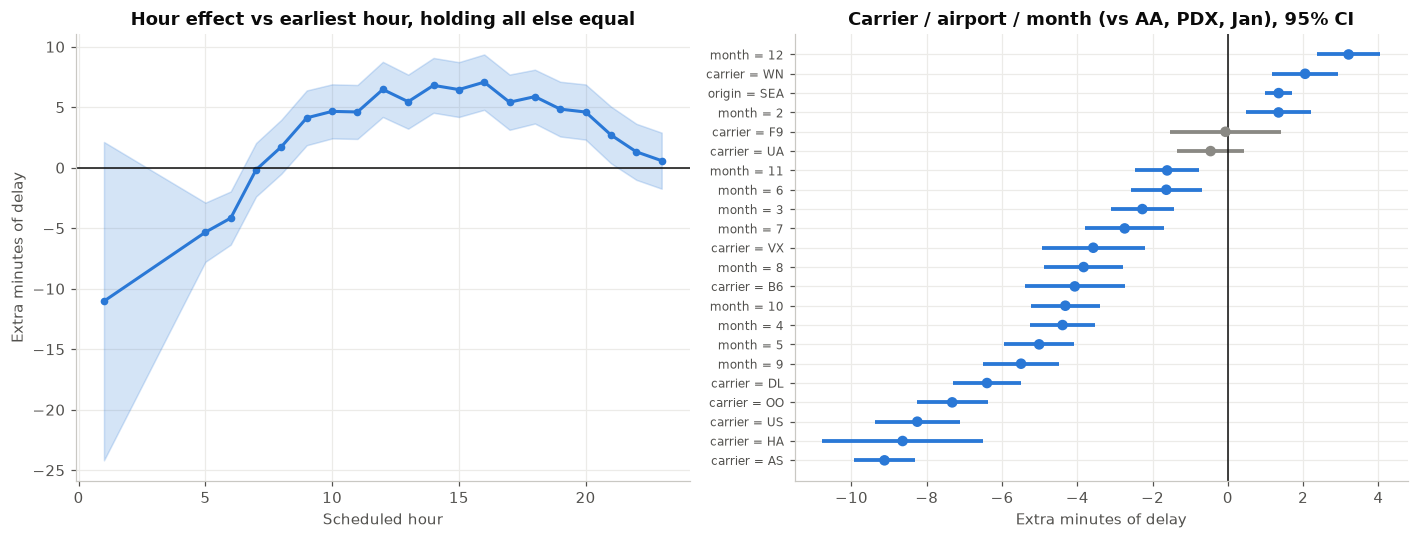

Weather effects (minutes per unit, holding time/carrier/airport fixed):


,coef,lo,hi,p
visib,-0.33,-0.41,-0.25,0.00
wind_speed,0.07,0.03,0.10,0.00
precip,14.30,4.13,24.46,0.01
humid,-0.08,-0.10,-0.07,0.00
temp,0.09,0.06,0.12,0.00
distance,0.00,0.00,0.00,0.00


In [19]:
# ---- The final linear model: which effects are real? ----
ols = fitted["4. Full (3 + weather)"]
ci = ols.conf_int()
coef = pd.DataFrame({"coef": ols.params, "lo": ci[0], "hi": ci[1], "p": ols.pvalues}).drop("Intercept")
label = lambda i: i.replace("C(", "").replace(")[T.", " = ").replace("[T.", " = ").replace("]", "")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Left: hour-of-day effect curve (reference = earliest scheduled hour)
hr = coef[coef.index.str.startswith("C(hour)")].copy()
hr.index = hr.index.str.extract(r"T\.(\d+)")[0].astype(int).values
hr = hr.sort_index()
axes[0].fill_between(hr.index, hr["lo"], hr["hi"], color=BLUE, alpha=.2)
axes[0].plot(hr.index, hr["coef"], color=BLUE, marker="o", ms=4, lw=2)
axes[0].axhline(0, color=INK, lw=1)
axes[0].set_title("Hour effect vs earliest hour, holding all else equal"); axes[0].set_xlabel("Scheduled hour"); axes[0].set_ylabel("Extra minutes of delay")
# Right: carrier, airport and month effects
other = coef[coef.index.str.contains("carrier|origin|month")].sort_values("coef")
sig = other["p"] < 0.05
axes[1].hlines(range(len(other)), other["lo"], other["hi"], color=[BLUE if x else GREY for x in sig], lw=2.5)
axes[1].scatter(other["coef"], range(len(other)), color=[BLUE if x else GREY for x in sig], s=35, zorder=3)
axes[1].axvline(0, color=INK, lw=1)
axes[1].set_yticks(range(len(other))); axes[1].set_yticklabels([label(i) for i in other.index], fontsize=8)
axes[1].set_title("Carrier / airport / month (vs AA, PDX, Jan), 95% CI"); axes[1].set_xlabel("Extra minutes of delay")
plt.tight_layout(); plt.show()

print("Weather effects (minutes per unit, holding time/carrier/airport fixed):")
display(coef.loc[["visib", "wind_speed", "precip", "humid", "temp", "distance"]])

Holding everything else equal:
- **A 4pm departure** runs about 11 minutes later than a 6am one.
- **Alaska** averages about 9 fewer minutes of delay than American.
- **December** adds about 3 minutes.
- **Weather effects are real but small.**

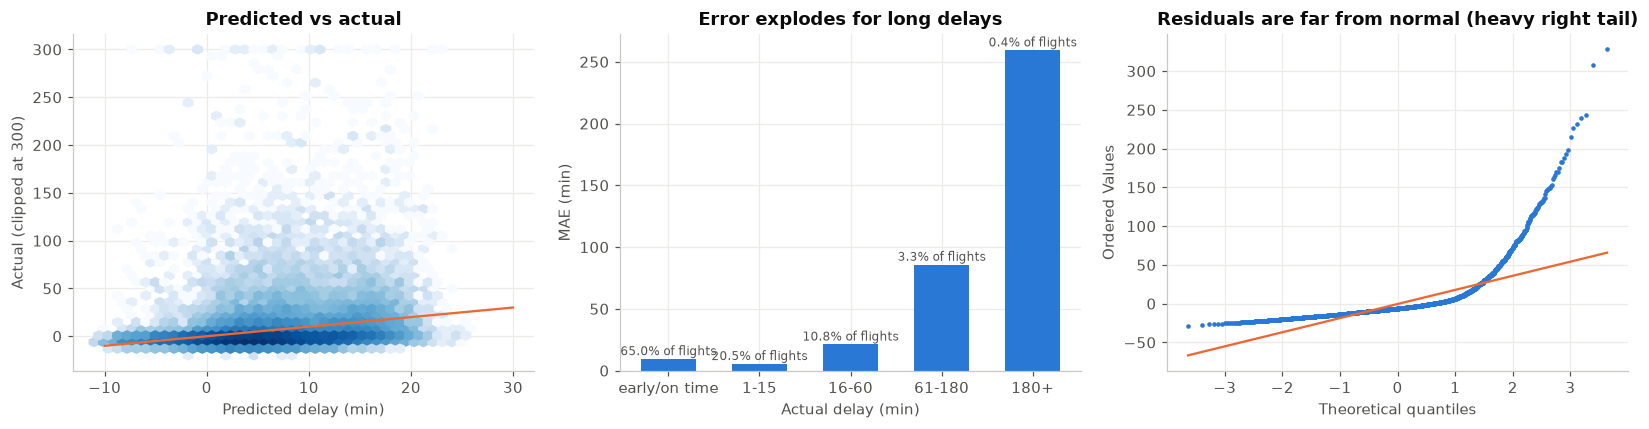

,MAE,bias,share
b,,,
early/on time,9.49,-9.22,0.65
1-15,5.52,-1.58,0.21
16-60,21.31,21.24,0.11
61-180,85.89,85.89,0.03
180+,259.41,259.41,0.00


In [20]:
# ---- Where the model fails ----
pred = ols.predict(test); resid = test["dep_delay"] - pred
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hb = axes[0].hexbin(pred, test["dep_delay"].clip(-30, 300), gridsize=40, bins="log", cmap="Blues", mincnt=1)
axes[0].plot([-10, 30], [-10, 30], color=ORANGE, lw=1.5)
axes[0].set_title("Predicted vs actual"); axes[0].set_xlabel("Predicted delay (min)"); axes[0].set_ylabel("Actual (clipped at 300)")

buckets = pd.cut(test["dep_delay"], [-100, 0, 15, 60, 180, 2000], labels=["early/on time", "1-15", "16-60", "61-180", "180+"])
err = pd.DataFrame({"b": buckets, "abs_err": resid.abs(), "bias": resid}).groupby("b", observed=True).agg(
    MAE=("abs_err", "mean"), bias=("bias", "mean"), share=("abs_err", "size"))
err["share"] /= err["share"].sum()
axes[1].bar(err.index.astype(str), err["MAE"], color=BLUE, width=0.6)
for i, (m_, s_) in enumerate(zip(err["MAE"], err["share"])):
    axes[1].text(i, m_ + 3, f"{s_:.1%} of flights", ha="center", fontsize=8, color=INK2)
axes[1].set_title("Error explodes for long delays"); axes[1].set_xlabel("Actual delay (min)"); axes[1].set_ylabel("MAE (min)")

stats.probplot(resid.sample(5000, random_state=1), dist="norm", plot=axes[2])
axes[2].get_lines()[0].set(color=BLUE, markersize=2); axes[2].get_lines()[1].set(color=ORANGE)
axes[2].set_title("Residuals are far from normal (heavy right tail)")
plt.tight_layout(); plt.show()
display(err)

**Where it fails:** it cannot foresee long delays. For flights 1–3 hours late, it underestimates by about 86 minutes. Those delays come from causes missing from the data: mechanical faults, crews, air-traffic holds, and aircraft arriving late from earlier flights.

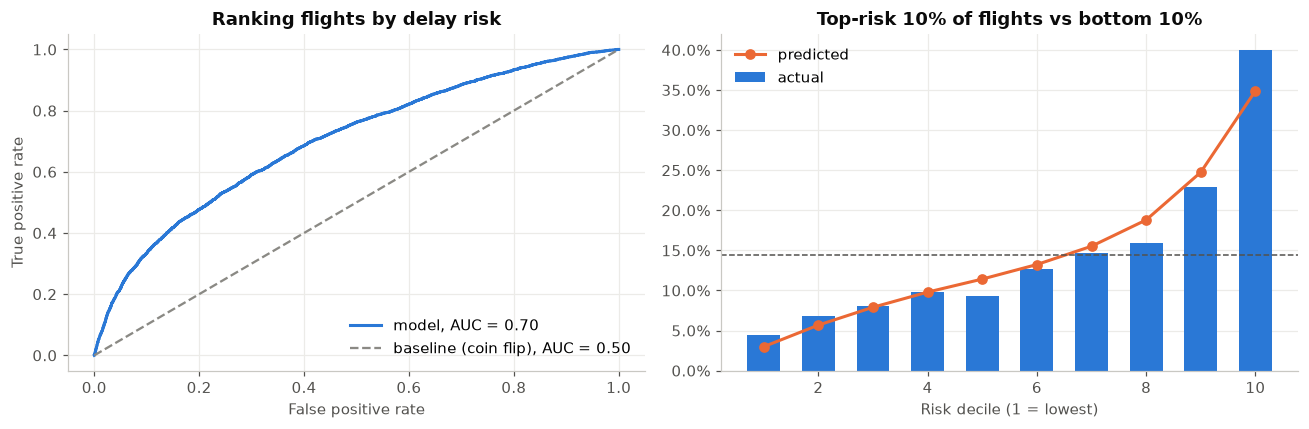

AUC 0.701 | top decile delay rate 40.0% vs bottom decile 4.5% (average 14.5%) -> 2.8x lift


In [21]:
# ---- A more useful framing: probability a flight is delayed >15 min (logistic regression) ----
logit = smf.logit("delayed15 ~ C(hour) + C(month) + C(carrier) + origin + visib + wind_speed + precip + humid + temp + distance",
                  data=train).fit(disp=0)
p_test = logit.predict(test)
auc = roc_auc_score(test["delayed15"], p_test)
fpr, tpr, _ = roc_curve(test["delayed15"], p_test)

test_r = test.assign(p=p_test, risk_decile=pd.qcut(p_test, 10, labels=range(1, 11)))
lift = test_r.groupby("risk_decile", observed=True).agg(predicted=("p", "mean"), actual=("delayed15", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color=BLUE, lw=2, label=f"model, AUC = {auc:.2f}")
axes[0].plot([0, 1], [0, 1], color=GREY, ls="--", label="baseline (coin flip), AUC = 0.50")
axes[0].set_title("Ranking flights by delay risk"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")
axes[1].bar(lift.index.astype(int), lift["actual"], color=BLUE, width=0.6, label="actual")
axes[1].plot(lift.index.astype(int), lift["predicted"], color=ORANGE, marker="o", lw=2, label="predicted")
axes[1].axhline(test["delayed15"].mean(), color=INK2, ls="--", lw=1)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title("Top-risk 10% of flights vs bottom 10%"); axes[1].set_xlabel("Risk decile (1 = lowest)"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"AUC {auc:.3f} | top decile delay rate {lift['actual'].iloc[-1]:.1%} vs bottom decile {lift['actual'].iloc[0]:.1%} "
      f"(average {test['delayed15'].mean():.1%}) -> {lift['actual'].iloc[-1] / test['delayed15'].mean():.1f}x lift")

**A more useful version** estimates the *probability* that a flight will be more than 15 minutes late.
- **It ranks flights well:** it scores 0.70 on a ranking scale where 0.5 is random guessing (AUC).
- **Its riskiest 10% of flights were delayed 40% of the time** (2.8× average); its safest 10%, 4.5%.
- **Its predicted probabilities track the actual delay rates.**

This is the version we recommend.

## 8. Recommendation
**What to do:**
1. **Buffer the afternoon.** Put standby crews, spare gates and extra turnaround time on departures scheduled **between 2pm and 8pm**. They are a third of the schedule and are delayed 20% of the time, against 7% for early-morning flights.
2. **Plan for December and freezing days**, using the freeze forecast to set staffing a day ahead.
3. **Engage the high-delay carriers** (Southwest, Frontier, United, JetBlue, American) on afternoon turnaround targets.
4. **Use the risk-ranking model daily** to flag which flights to watch, not to forecast minutes.

**How confident we are:**
- **High** that time of day, season and carrier drive risk: the effects are large and their ranges narrow.
- **Moderate** on the size of each weather effect, because extreme-weather hours are rare.

**What this does not establish:**
- **Cause and effect.** The afternoon pattern may reflect delays carried over from earlier flights.
- **Long delays and cancellations**, whose causes are missing from the data.
- **Other years or airports.** The data covers only 2014 at two airports, and carriers have since merged (US Airways into American).
- **Weather at the destination airport.**

## Division of work
*(Replace with your team's actual contributions.)*
- **[Member 1]:** Joined the datasets, investigated the unmatched flights and wrote the data-preparation narrative.
- **[Member 2]:** Led the cleaning, including finding the actual-vs-scheduled hour problem, and built the cleaning log.
- **[Member 3]:** Built the visualizations and the confidence-interval analysis.
- **[Member 4]:** Built and evaluated the regression models and drafted the recommendation.

**AI use statement (Hult AI policy):** *[State how AI tools were used, per your course's policy.]*